# Transfer Learning (Aprendizado por Transferência) para Diagnóstico de Falhas

**Projeto:** Diagnóstico de Falhas em Rolamentos via CNN + Transformada Wavelet Contínua  
**Dataset:** Escalogramas CWT (CWRU - 4 classes: `normal`, `ball`, `inner_race`, `outer_race`)  
**Objetivo:** Executar experimentos de Transfer Learning com modelos pré-treinados no ImageNet (**ResNet-18**, **Inception-v3** e **EfficientNet-B0**) em blocos de código separados e independentes, invocando o módulo `src.transfer_learning`, conforme abordado no Referencial Teórico da Monografia (Seção 2.4 e Tabela 4).

---

## 1. Importação de Bibliotecas e Módulos do Projeto

In [ ]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Importar configurações e motor de Transfer Learning de src/
from src.config import NUM_EPOCHS, LEARNING_RATE
from src.transfer_learning import train_and_evaluate_transfer_model

from src.visualization import plot_training_curves, plot_confusion_matrix

# Dicionário global para consolidar todos os resultados
resultados = {}

## 2. Experimento 1: ResNet-18

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão da **ResNet-18**.

In [ ]:
# Treinamento da ResNet-18
res_resnet = train_and_evaluate_transfer_model('resnet18', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['resnet18'] = res_resnet

[INFO] Figura salva em: ../docs/images/training_curves_resnet.png


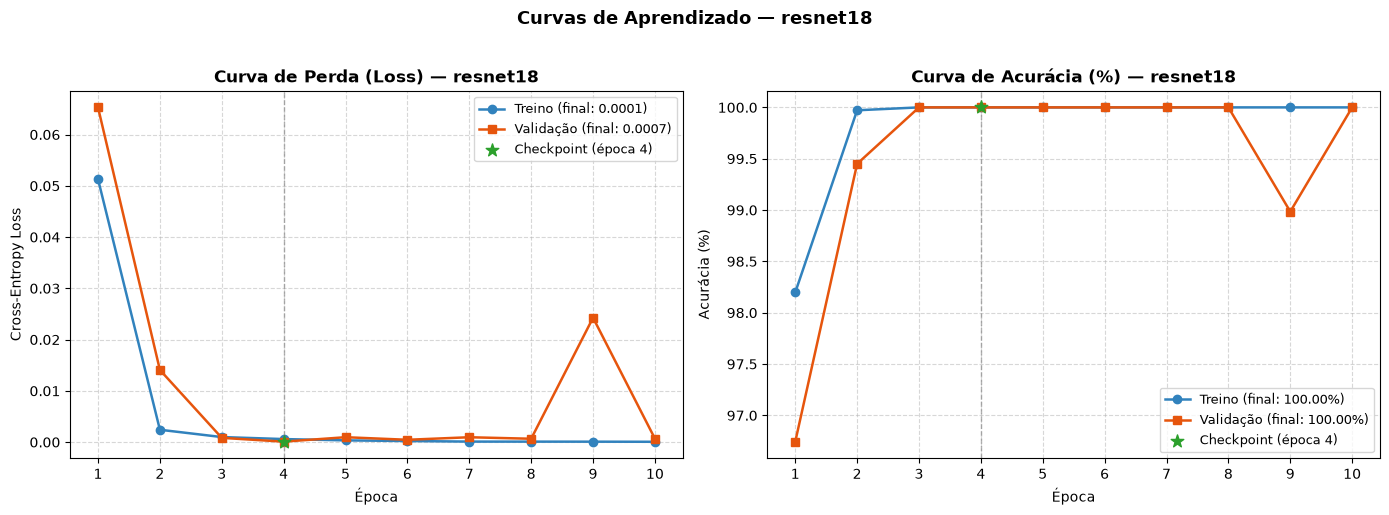

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (RESNET-18) ===
              precision    recall  f1-score   support

        ball     0.9256    1.0000    0.9614       473
  inner_race     1.0000    0.9197    0.9581       473
      normal     1.0000    1.0000    1.0000       947
  outer_race     1.0000    1.0000    1.0000       475

    accuracy                         0.9840      2368
   macro avg     0.9814    0.9799    0.9799      2368
weighted avg     0.9851    0.9840    0.9839      2368

[INFO] Figura salva em: ../docs/images/confusion_matrix_resnet.png


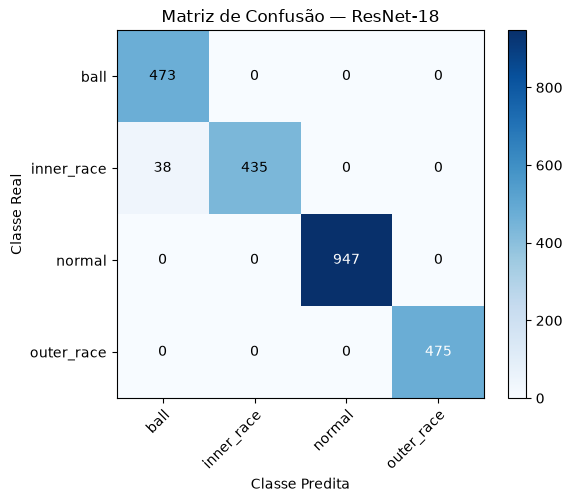

In [11]:
# --- 1. Curvas de Aprendizado ---
plot_training_curves(res_resnet['history'], 'resnet18',
                      save_path='../docs/images/training_curves_resnet.png')

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (RESNET-18) ===')
print(classification_report(res_resnet['test_labels'], res_resnet['test_preds'], target_names=res_resnet['classes'], digits=4))

# --- 3. Matriz de Confusão ---
plot_confusion_matrix(res_resnet, 'ResNet-18', save_path='../docs/images/confusion_matrix_resnet.png')


## 3. Experimento 2: Inception-v3

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão do **Inception-v3** (com imagens redimensionadas para $299 \times 299$).

In [ ]:
# Treinamento do Inception-v3
res_inception = train_and_evaluate_transfer_model('inception_v3', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['inception_v3'] = res_inception


[INFO] Figura salva em: ../docs/images/training_curves_inception.png


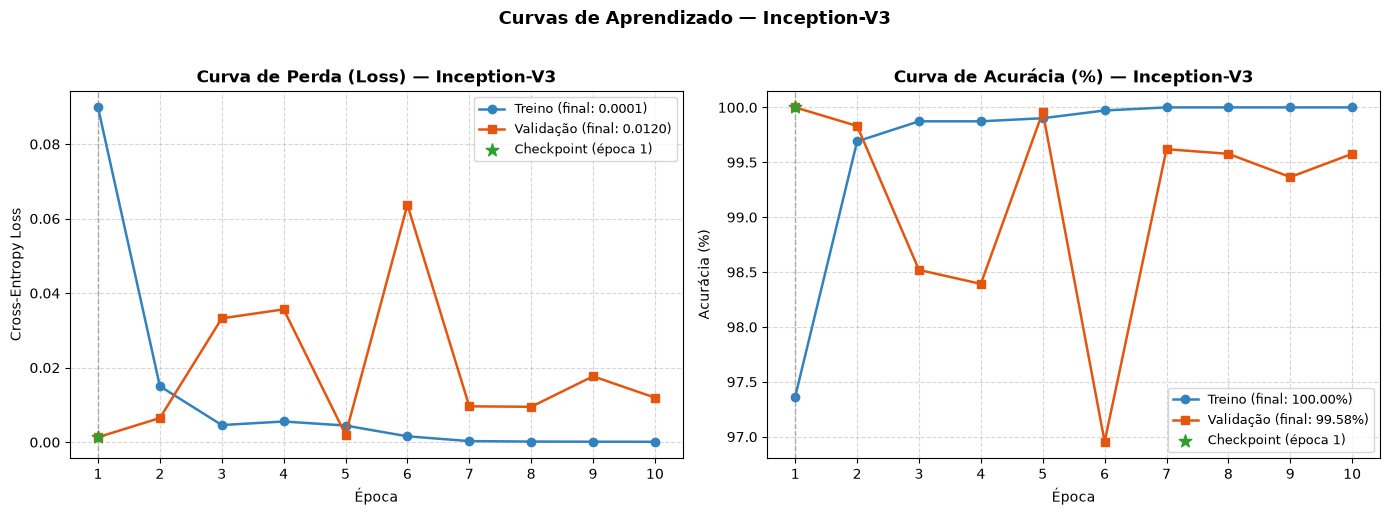

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (INCEPTION-V3) ===
              precision    recall  f1-score   support

        ball     0.9812    0.9937    0.9874       473
  inner_race     0.9978    0.9810    0.9893       473
      normal     1.0000    1.0000    1.0000       947
  outer_race     0.9958    1.0000    0.9979       475

    accuracy                         0.9949      2368
   macro avg     0.9937    0.9937    0.9937      2368
weighted avg     0.9950    0.9949    0.9949      2368

[INFO] Figura salva em: ../docs/images/confusion_matrix_inception.png


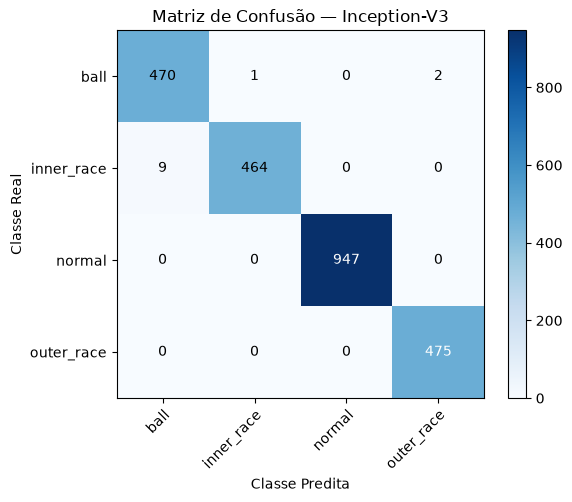

In [10]:
# --- 1. Curvas de Aprendizado ---
plot_training_curves(res_inception['history'], 'Inception-V3',
                      save_path='../docs/images/training_curves_inception.png')

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (INCEPTION-V3) ===')
print(classification_report(res_inception['test_labels'], res_inception['test_preds'], target_names=res_inception['classes'], digits=4))

# --- 3. Matriz de Confusão ---
plot_confusion_matrix(res_inception, 'Inception-V3', save_path='../docs/images/confusion_matrix_inception.png')

## 4. Experimento 3: EfficientNet-B0

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão do **EfficientNet-B0**.

In [ ]:
# Treinamento do EfficientNet-B0
res_efficientnet = train_and_evaluate_transfer_model('efficientnet_b0', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['efficientnet_b0'] = res_efficientnet


[INFO] Figura salva em: ../docs/images/training_curves_efficientnet.png


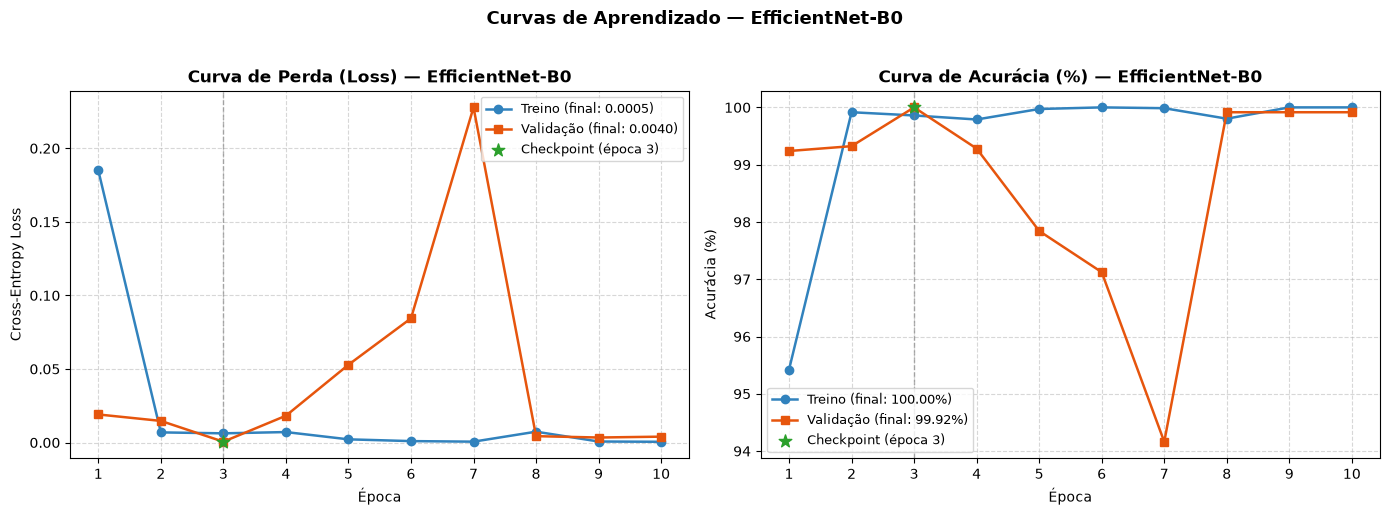

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (EFFICIENTNET-B0) ===
              precision    recall  f1-score   support

        ball     0.9831    0.9852    0.9842       473
  inner_race     0.9957    0.9831    0.9894       473
      normal     1.0000    1.0000    1.0000       947
  outer_race     0.9896    1.0000    0.9948       475

    accuracy                         0.9937      2368
   macro avg     0.9921    0.9921    0.9921      2368
weighted avg     0.9937    0.9937    0.9937      2368

[INFO] Figura salva em: ../docs/images/confusion_matrix_efficientnet.png


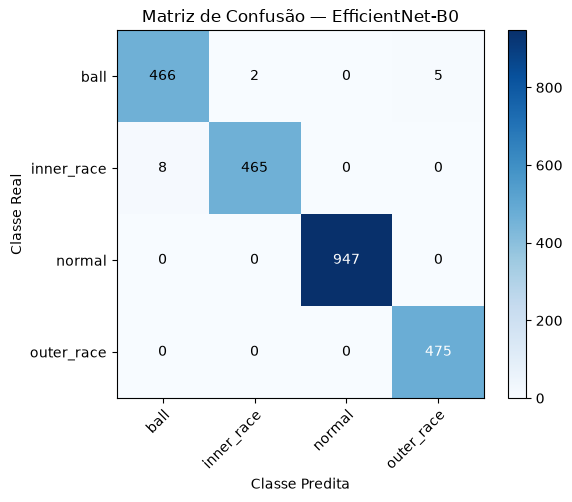

In [9]:
# --- 1. Curvas de Aprendizado ---
plot_training_curves(res_efficientnet['history'], 'EfficientNet-B0',
                      save_path='../docs/images/training_curves_efficientnet.png')

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (EFFICIENTNET-B0) ===')
print(classification_report(res_efficientnet['test_labels'], res_efficientnet['test_preds'], target_names=res_efficientnet['classes'], digits=4))

# --- 3. Matriz de Confusão ---
plot_confusion_matrix(res_efficientnet, 'EfficientNet-B0', save_path='../docs/images/confusion_matrix_efficientnet.png')

## 5. Tabela Comparativa Geral de Desempenho 



In [ ]:
print('================================================================================')
print(' TABELA COMPARATIVA DE MODELOS — DIAGNÓSTICO DE FALHAS EM ROLAMENTOS (TCC) ')
print('================================================================================')
print(f'{"Modelo":<22s} | {"Estratégia":<16s} | {"Acurácia Val (%)":<18s} | {"Acurácia Teste (%)":<18s}')
print('-' * 80)

for nome_modelo, res in resultados.items():
    print(f'{res["model_name"].upper():<22s} | {"Transfer Learning":<16s} | {res["best_val_acc"]:<17.2f}% | {res["test_acc"]:<17.2f}%')
print('================================================================================')